In [1]:
import pandas as np
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

C:\Users\suma\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [80]:
df = pd.read_csv("fraudTest.csv")

df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,...,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
555715,555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,...,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
555716,555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,...,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
555717,555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,...,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


In [81]:
df.shape

(555719, 23)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [83]:
df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [84]:
import pandas as pd
df = pd.read_csv("fraudTest.csv")
Q1 = df["amt"].quantile(0.25)
Q3 = df["amt"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["amt_outlier"] = ((df["amt"] < lower_bound) | (df["amt"] > upper_bound)).astype(int)
print(df["amt_outlier"].value_counts())
df.to_csv("fraudTest_flagged.csv", index=False)



0    527941
1     27778
Name: amt_outlier, dtype: int64


In [85]:
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,amt_outlier
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,...,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0,0
555715,555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,...,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0,0
555716,555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,...,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0,0
555717,555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,...,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0,0


In [86]:
print(df.groupby("amt_outlier")["is_fraud"].mean())


amt_outlier
0    0.001008
1    0.058068
Name: is_fraud, dtype: float64


In [87]:
from sklearn.preprocessing import MinMaxScaler

columns_to_scale = ['amt', 'city_pop', 'unix_time', 'lat', 'long', 'merch_lat', 'merch_long']

scaler = MinMaxScaler()
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

In [88]:
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,amt_outlier
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,0.000082,Jeff,Elliott,M,351 Darlene Green,...,0.867121,0.114727,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,0.000000e+00,0.313922,0.857112,0,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,0.001267,Joanne,Williams,F,3638 Marsh Union,...,0.565239,0.000096,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,4.785402e-07,0.428589,0.568706,0,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,0.001769,Ashley,Lopez,F,9333 Valentine Point,...,0.942836,0.011860,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1.674891e-06,0.450526,0.927355,0,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,0.002594,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,0.868312,0.018834,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,2.990876e-06,0.205343,0.860298,0,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,0.000096,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,0.825355,0.000379,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,3.110511e-06,0.544191,0.810140,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,0.001879,Michael,Olson,M,558 Michael Estates,...,0.755010,0.000171,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,9.999984e-01,0.439005,0.755501,0,0
555715,555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,0.004868,Jose,Vasquez,M,572 Davis Mountains,...,0.718694,0.009879,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,9.999985e-01,0.223152,0.706832,0,0
555716,555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,0.003772,Ann,Lawson,F,144 Evans Islands Apt. 683,...,0.478609,0.001260,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,9.999989e-01,0.579850,0.470886,0,0
555717,555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,0.000307,Eric,Preston,M,7020 Doyle Stream Apt. 951,...,0.503704,0.000036,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,9.999994e-01,0.533937,0.497302,0,0


In [89]:
import numpy as np

# Convert transaction date to datetime format
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extract new time-based features
df['transaction_hour'] = df['trans_date_trans_time'].dt.hour
df['transaction_day'] = df['trans_date_trans_time'].dt.dayofweek  # 0 = Monday, 6 = Sunday

# Categorize transaction amount
df['amt_category'] = pd.cut(df['amt'], bins=[0, 50, 200, np.inf], labels=['low', 'medium', 'high'])

# Identify high-risk states/cities (Example: If a city has >100 frauds, mark as risky)
fraud_counts = df.groupby('city')['is_fraud'].sum()
risky_cities = fraud_counts[fraud_counts > 100].index
df['risky_city'] = df['city'].apply(lambda x: 1 if x in risky_cities else 0)

# User-based fraud risk features
df['user_fraud_count'] = df.groupby('cc_num')['is_fraud'].transform('sum')  # Fraud count per user
df['user_avg_amt'] = df.groupby('cc_num')['amt'].transform('mean')  # Average spending per user

# Drop original datetime column after feature extraction
df.drop(columns=['trans_date_trans_time'], inplace=True)

In [90]:
df

,Unnamed: 0,cc_num,merchant,category,amt,first,last,gender,street,city,...,merch_lat,merch_long,is_fraud,amt_outlier,transaction_hour,transaction_day,amt_category,risky_city,user_fraud_count,user_avg_amt
0,0,2291163933867244,fraud_Kirlin and Sons,personal_care,0.000082,Jeff,Elliott,M,351 Darlene Green,Columbia,...,0.313922,0.857112,0,0,12,6,low,0,0,0.002675
1,1,3573030041201292,fraud_Sporer-Keebler,personal_care,0.001267,Joanne,Williams,F,3638 Marsh Union,Altonah,...,0.428589,0.568706,0,0,12,6,low,0,0,0.002310
2,2,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,0.001769,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,0.450526,0.927355,0,0,12,6,low,0,0,0.003604
3,3,3591919803438423,fraud_Haley Group,misc_pos,0.002594,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,...,0.205343,0.860298,0,0,12,6,low,0,10,0.002557
4,4,3526826139003047,fraud_Johnston-Casper,travel,0.000096,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,...,0.544191,0.810140,0,0,12,6,low,0,0,0.002384
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,30560609640617,fraud_Reilly and Sons,health_fitness,0.001879,Michael,Olson,M,558 Michael Estates,Luray,...,0.439005,0.755501,0,0,23,3,low,0,11,0.003145
555715,555715,3556613125071656,fraud_Hoppe-Parisian,kids_pets,0.004868,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,...,0.223152,0.706832,0,0,23,3,low,0,0,0.002000
555716,555716,6011724471098086,fraud_Rau-Robel,kids_pets,0.003772,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,...,0.579850,0.470886,0,0,23,3,low,0,0,0.004027
555717,555717,4079773899158,fraud_Breitenberg LLC,travel,0.000307,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,...,0.533937,0.497302,0,0,23,3,low,0,0,0.002509


In [91]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Encode categorical columns efficiently
label_enc = LabelEncoder()
for col in categorical_cols:
    df[col] = df[col].astype(str)  # Convert to string to avoid issues

    if df[col].nunique() <= 10:  # One-Hot Encoding for small categories
        df = pd.get_dummies(df, columns=[col])
    else:  # Label Encoding for high-cardinality columns
        df[col] = label_enc.fit_transform(df[col])


In [92]:
df

,Unnamed: 0,cc_num,merchant,category,amt,first,last,street,city,state,...,amt_outlier,transaction_hour,transaction_day,risky_city,user_fraud_count,user_avg_amt,gender_F,gender_M,amt_category_low,amt_category_nan
0,0,2291163933867244,319,10,0.000082,151,115,341,157,39,...,0,12,6,0,0,0.002675,0,1,1,0
1,1,3573030041201292,591,10,0.001267,163,457,354,16,43,...,0,12,6,0,0,0.002310,1,0,1,0
2,2,3598215285024754,611,5,0.001769,24,249,865,61,33,...,0,12,6,0,0,0.003604,1,0,1,0
3,3,3591919803438423,222,9,0.002594,42,457,320,764,8,...,0,12,6,0,10,0.002557,0,1,1,0
4,4,3526826139003047,292,13,0.000096,247,261,548,247,21,...,0,12,6,0,0,0.002384,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,30560609640617,507,5,0.001879,235,315,531,443,23,...,0,23,3,0,11,0.003145,0,1,1,0
555715,555715,3556613125071656,264,7,0.004868,171,424,540,401,42,...,0,23,3,0,0,0.002000,0,1,1,0
555716,555716,6011724471098086,496,7,0.003772,18,239,126,104,46,...,0,23,3,0,0,0.004027,1,0,1,0
555717,555717,4079773899158,75,13,0.000307,111,342,663,476,12,...,0,23,3,0,0,0.002509,0,1,1,0


In [94]:
df.to_csv("fraudTest_feature_engineered1.csv", index=False)

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn Style
sns.set(style="whitegrid")

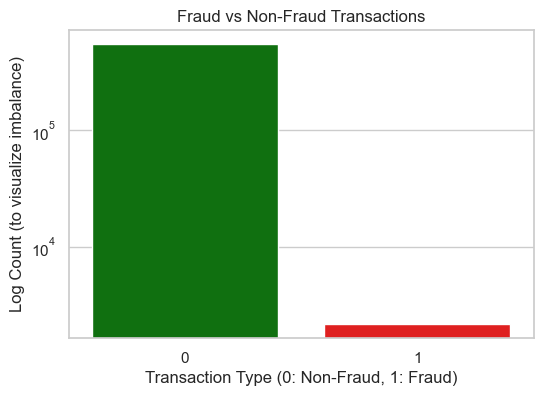

In [96]:
# Class Distribution (Fraud vs Non-Fraud)
plt.figure(figsize=(6,4))
ax = sns.countplot(x=df['is_fraud'], palette=['green', 'red'])

# Use log scale to highlight the difference
ax.set_yscale('log')

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Type (0: Non-Fraud, 1: Fraud)")
plt.ylabel("Log Count (to visualize imbalance)")
plt.show()


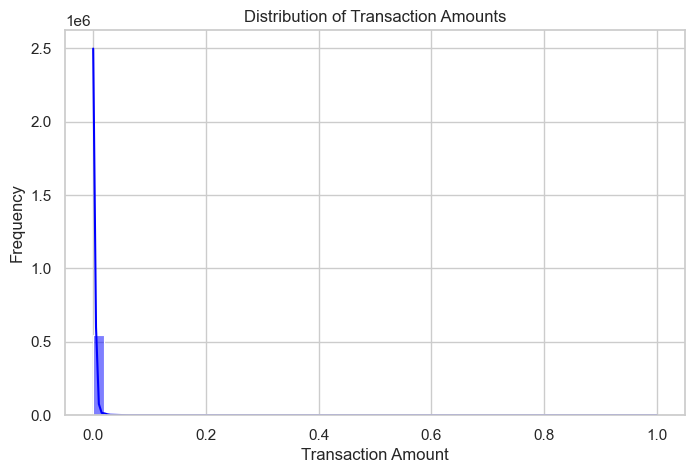

In [97]:
#  Transaction Amount Distribution (Histogram)
plt.figure(figsize=(8,5))
sns.histplot(df['amt'], bins=50, kde=True, color="blue")
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

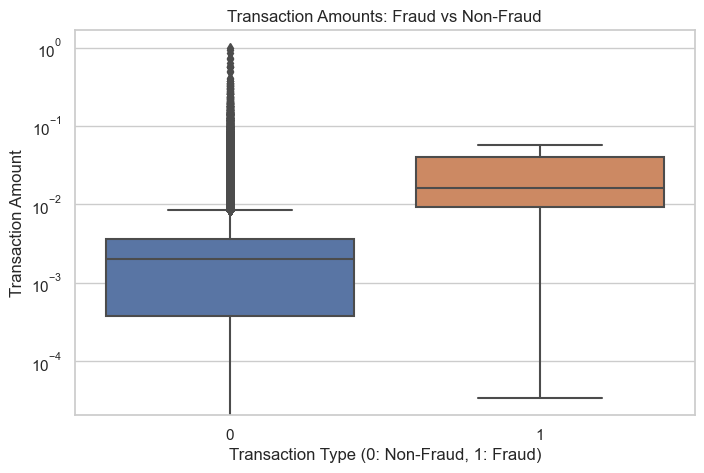

In [98]:
#  Fraud vs Non-Fraud Transaction Amounts (Box Plot)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['is_fraud'], y=df['amt'], showfliers=True)  # Ensure outliers are visible
plt.yscale('log')  # Log scale for better visualization
plt.xlabel('Transaction Type (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Transaction Amount')
plt.title('Transaction Amounts: Fraud vs Non-Fraud')
plt.show()

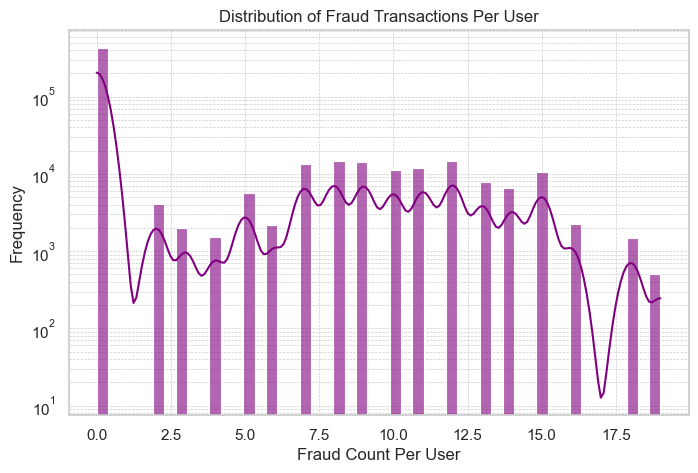

In [99]:
#  User Fraud Count Distribution (Histogram)
plt.figure(figsize=(8, 5))
sns.histplot(df['user_fraud_count'], bins=50, kde=True, color="purple", alpha=0.6, stat="count")

plt.yscale("log")  # Log scale for better visualization
plt.grid(True, which="both", linestyle="--", linewidth=0.5)  

plt.title("Distribution of Fraud Transactions Per User")
plt.xlabel("Fraud Count Per User")
plt.ylabel("Frequency")

plt.show()


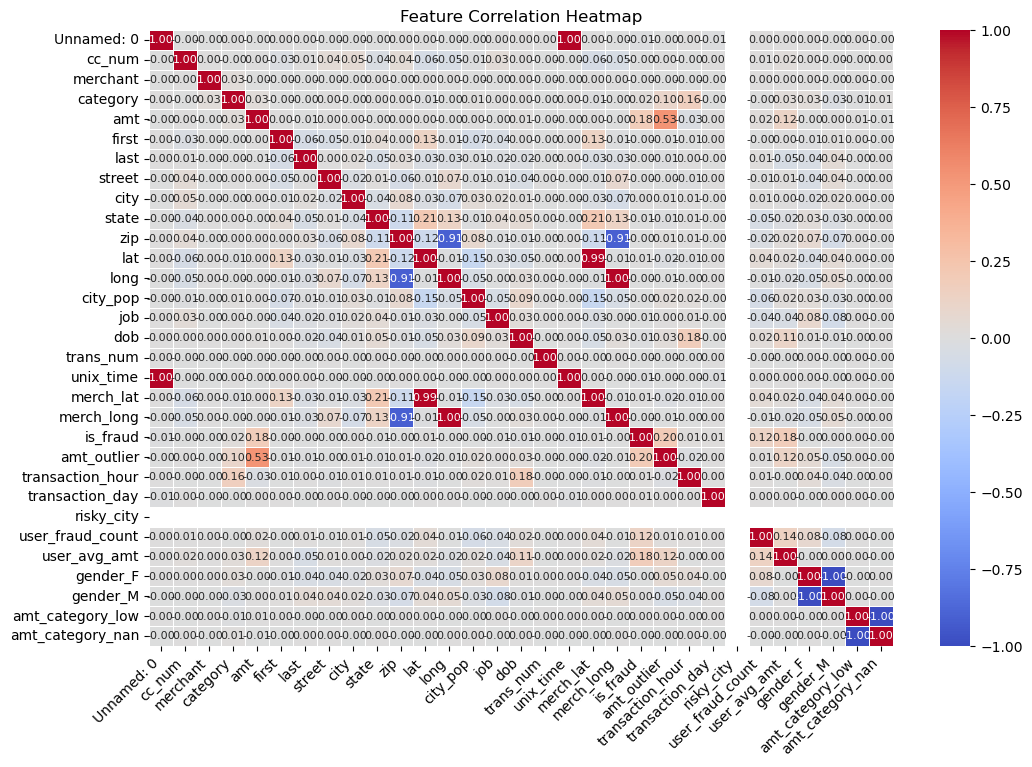

In [6]:
# Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns
corr_matrix = df.corr()  # Compute correlation matrix

plt.figure(figsize=(12, 8))  # Increase figure size
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            linewidths=0.5, annot_kws={"size": 8})

plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels
plt.yticks(rotation=0)  # Keep y-axis labels horizontal
plt.show()

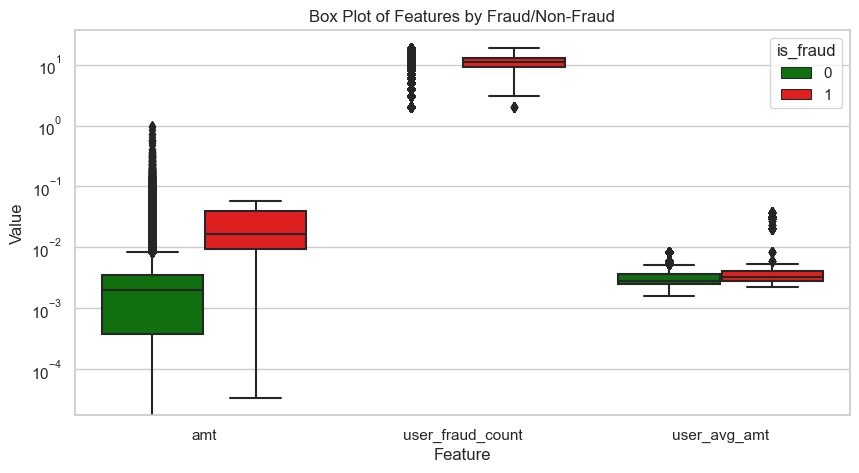

In [101]:
#  Box Plot for Feature Distributions
numeric_features = ['amt', 'user_fraud_count', 'user_avg_amt']


df['is_fraud'] = df['is_fraud'].astype(int)

df_melted = df.melt(id_vars="is_fraud", value_vars=numeric_features)


plt.figure(figsize=(10, 5))

sns.boxplot(x="variable", y="value", hue="is_fraud", data=df_melted, palette={0: "green", 1: "red"})

plt.title("Box Plot of Features by Fraud/Non-Fraud")
plt.xlabel("Feature")
plt.ylabel("Value")

plt.yscale("log")

plt.show()
